<a href="https://colab.research.google.com/github/ayesha0908/Smart-AI-Study-Planner/blob/main/Smart_AI_Study_Planner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Smart AI Study Planner

subjects = {}

# Difficulty weights
difficulty_weights = {
    "Easy": 1,
    "Medium": 2,
    "Hard": 3
}

# Strength weights
strength_weights = {
    "Strong": 1,
    "Average": 2,
    "Weak": 3
}

# Number of subjects
n = int(input("Enter number of subjects: "))

# Input subject details
for i in range(n):

    name = input(f"\nEnter subject {i+1} name: ")

    difficulty = input(
        f"Difficulty for {name} (Easy/Medium/Hard): "
    )

    strength = input(
        f"Your level in {name} (Strong/Average/Weak): "
    )

    subjects[name] = {
        "difficulty": difficulty,
        "strength": strength
    }

# Study hours available
study_hours = float(
    input("\nEnter study hours available per day: ")
)

# Calculate priorities
priority_scores = {}

for subject, details in subjects.items():

    difficulty_score = difficulty_weights[
        details["difficulty"]
    ]

    strength_score = strength_weights[
        details["strength"]
    ]

    total_score = difficulty_score + strength_score

    priority_scores[subject] = total_score

# Total score
sum_scores = sum(priority_scores.values())


print("\n--------- STUDY PLAN ---------\n")

for subject, score in priority_scores.items():

    allocated_hours = (
        score/sum_scores
    ) * study_hours

    print(
        subject,
        "→",
        round(allocated_hours,2),
        "hours"
    )

print("\n--------- PRIORITY RANKING ---------\n")

sorted_subjects = sorted(
    priority_scores.items(),
    key=lambda x:x[1],
    reverse=True
)

rank=1

for subject, score in sorted_subjects:

    print(
        rank,
        ".",
        subject,
        "(Priority Score:",
        score,
        ")"
    )

    rank +=1

from datetime import datetime

print("\n----- EXAM DATE INPUT -----\n")

exam_days = {}

for subject in subjects:

    days = int(
        input(
            f"Days left for {subject} exam: "
        )
    )

    exam_days[subject] = days


# Calculate updated priority

updated_scores = {}

for subject in subjects:

    old_score = priority_scores[subject]

    days_left = exam_days[subject]

    # Closer exam = higher bonus
    exam_bonus = 0

    if days_left <= 3:
        exam_bonus = 3

    elif days_left <= 7:
        exam_bonus = 2

    elif days_left <= 14:
        exam_bonus = 1

    new_score = old_score + exam_bonus

    updated_scores[subject] = new_score


print("\n----- UPDATED PRIORITIES -----\n")

for subject, score in updated_scores.items():

    print(
        subject,
        "→ Priority:",
        score
    )


Enter number of subjects: 3

Enter subject 1 name: Math
Difficulty for Math (Easy/Medium/Hard): Hard
Your level in Math (Strong/Average/Weak): Weak

Enter subject 2 name: DSA
Difficulty for DSA (Easy/Medium/Hard): Medium
Your level in DSA (Strong/Average/Weak): Average

Enter subject 3 name: OS
Difficulty for OS (Easy/Medium/Hard): Hard
Your level in OS (Strong/Average/Weak): Average

Enter study hours available per day: 8

--------- STUDY PLAN ---------

Math → 3.2 hours
DSA → 2.13 hours
OS → 2.67 hours

--------- PRIORITY RANKING ---------

1 . Math (Priority Score: 6 )
2 . OS (Priority Score: 5 )
3 . DSA (Priority Score: 4 )

----- EXAM DATE INPUT -----

Days left for Math exam: 3
Days left for DSA exam: 6
Days left for OS exam: 10

----- UPDATED PRIORITIES -----

Math → Priority: 9
DSA → Priority: 6
OS → Priority: 6


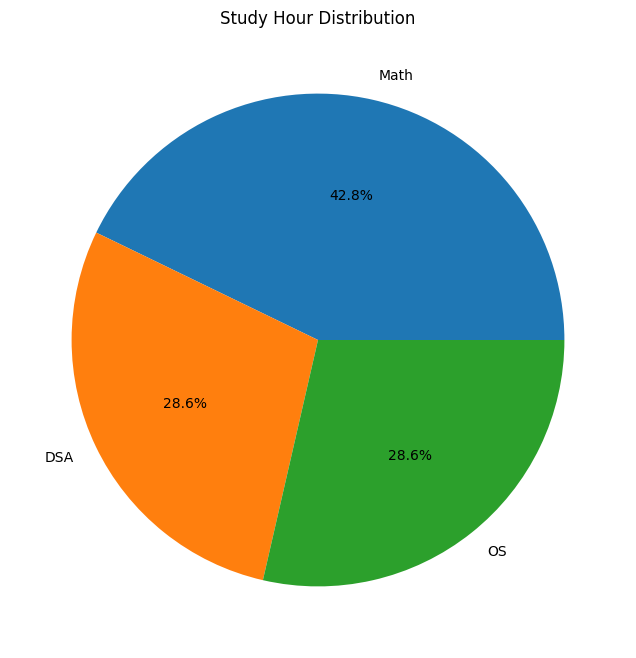

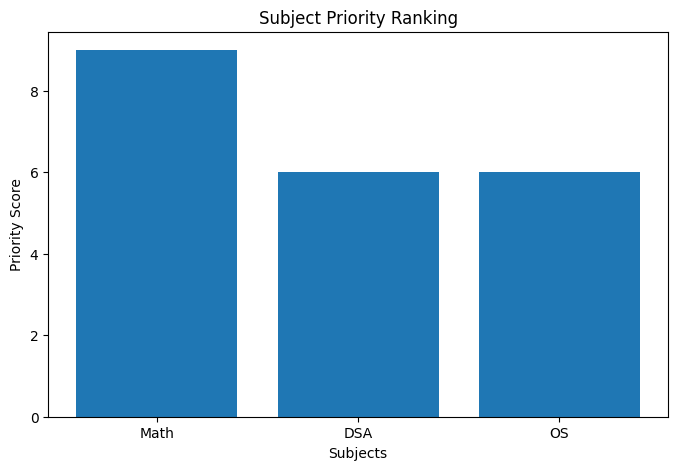

In [13]:
import matplotlib.pyplot as plt

# Recalculate total updated score
total_updated_score = sum(updated_scores.values())

# Allocate hours again using updated priorities
new_hours = {}

for subject, score in updated_scores.items():

    hours = (score / total_updated_score) * study_hours

    new_hours[subject] = round(hours,2)


# ---------------- PIE CHART ---------------- #

plt.figure(figsize=(8,8))

plt.pie(
    new_hours.values(),
    labels=new_hours.keys(),
    autopct="%1.1f%%"
)

plt.title("Study Hour Distribution")

plt.show()


# ---------------- BAR GRAPH ---------------- #

plt.figure(figsize=(8,5))

plt.bar(
    updated_scores.keys(),
    updated_scores.values()
)

plt.xlabel("Subjects")

plt.ylabel("Priority Score")

plt.title("Subject Priority Ranking")

plt.show()

In [14]:
print("\n--------- 7 DAY STUDY SCHEDULE ---------\n")

days = 7

for day in range(1, days+1):

    print(f"\nDay {day}")

    print("-"*20)

    for subject, hours in new_hours.items():

        daily_hours = round(hours,1)

        print(
            subject,
            "→",
            daily_hours,
            "hours"
        )


--------- 7 DAY STUDY SCHEDULE ---------


Day 1
--------------------
Math → 3.4 hours
DSA → 2.3 hours
OS → 2.3 hours

Day 2
--------------------
Math → 3.4 hours
DSA → 2.3 hours
OS → 2.3 hours

Day 3
--------------------
Math → 3.4 hours
DSA → 2.3 hours
OS → 2.3 hours

Day 4
--------------------
Math → 3.4 hours
DSA → 2.3 hours
OS → 2.3 hours

Day 5
--------------------
Math → 3.4 hours
DSA → 2.3 hours
OS → 2.3 hours

Day 6
--------------------
Math → 3.4 hours
DSA → 2.3 hours
OS → 2.3 hours

Day 7
--------------------
Math → 3.4 hours
DSA → 2.3 hours
OS → 2.3 hours


In [15]:
print("\n--------- SMART 7-DAY STUDY SCHEDULE ---------\n")

days = 7

temp_hours = new_hours.copy()

for day in range(1, days+1):

    print(f"\nDay {day}")

    print("-"*25)

    sorted_subjects = sorted(
        temp_hours.items(),
        key=lambda x:x[1],
        reverse=True
    )

    for subject, hours in sorted_subjects:

        study_today = round(hours,1)

        print(
            subject,
            "→",
            study_today,
            "hours"
        )

        temp_hours[subject] = max(
            0.5,
            hours-0.3
        )


--------- SMART 7-DAY STUDY SCHEDULE ---------


Day 1
-------------------------
Math → 3.4 hours
DSA → 2.3 hours
OS → 2.3 hours

Day 2
-------------------------
Math → 3.1 hours
DSA → 2.0 hours
OS → 2.0 hours

Day 3
-------------------------
Math → 2.8 hours
DSA → 1.7 hours
OS → 1.7 hours

Day 4
-------------------------
Math → 2.5 hours
DSA → 1.4 hours
OS → 1.4 hours

Day 5
-------------------------
Math → 2.2 hours
DSA → 1.1 hours
OS → 1.1 hours

Day 6
-------------------------
Math → 1.9 hours
DSA → 0.8 hours
OS → 0.8 hours

Day 7
-------------------------
Math → 1.6 hours
DSA → 0.5 hours
OS → 0.5 hours


In [16]:
import pandas as pd

schedule = []

for day in range(1, 8):

    daily_plan = {"Day": f"Day {day}"}

    for subject, hours in temp_hours.items():

        daily_plan[subject] = round(hours,1)

    schedule.append(daily_plan)


schedule_df = pd.DataFrame(schedule)

print("\nSTUDY SCHEDULE TABLE\n")

display(schedule_df)


STUDY SCHEDULE TABLE



,Day,Math,DSA,OS
0,Day 1,1.3,0.5,0.5
1,Day 2,1.3,0.5,0.5
2,Day 3,1.3,0.5,0.5
3,Day 4,1.3,0.5,0.5
4,Day 5,1.3,0.5,0.5
5,Day 6,1.3,0.5,0.5
6,Day 7,1.3,0.5,0.5


In [25]:
print("\n--------- PERSONALIZED STUDY STRATEGY ---------\n")

for subject, details in subjects.items():

    difficulty = details["difficulty"]
    strength = details["strength"]

    total_hours = round(new_hours[subject],1)

    print(f"\n{subject}")
    print("-"*20)

    if difficulty=="Hard" and strength=="Weak":

        theory = round(total_hours*0.5,1)
        practice = round(total_hours*0.3,1)
        revision = round(total_hours*0.2,1)

    elif difficulty=="Medium":

        theory = round(total_hours*0.3,1)
        practice = round(total_hours*0.5,1)
        revision = round(total_hours*0.2,1)

    else:

        theory = round(total_hours*0.2,1)
        practice = round(total_hours*0.4,1)
        revision = round(total_hours*0.4,1)

    print(f"Theory: {theory} hrs")
    print(f"Practice: {practice} hrs")
    print(f"Revision: {revision} hrs")


--------- PERSONALIZED STUDY STRATEGY ---------


Math
--------------------
Theory: 1.7 hrs
Practice: 1.0 hrs
Revision: 0.7 hrs

DSA
--------------------
Theory: 0.7 hrs
Practice: 1.1 hrs
Revision: 0.5 hrs

OS
--------------------
Theory: 0.5 hrs
Practice: 0.9 hrs
Revision: 0.9 hrs


In [28]:
print("\n--------- PRIORITY EXPLANATION ---------\n")

for subject, details in subjects.items():

    difficulty = details["difficulty"]
    strength = details["strength"]

    print(f"\n{subject}")
    print("-"*20)

    print(f"Difficulty: {difficulty}")
    print(f"Your Level: {strength}")
    print(f"Exam in: {exam_days[subject]} days")
    print(f"Final Priority Score: {updated_scores[subject]}")


--------- PRIORITY EXPLANATION ---------


Math
--------------------
Difficulty: Hard
Your Level: Weak
Exam in: 3 days
Final Priority Score: 9

DSA
--------------------
Difficulty: Medium
Your Level: Average
Exam in: 6 days
Final Priority Score: 6

OS
--------------------
Difficulty: Hard
Your Level: Average
Exam in: 10 days
Final Priority Score: 6
